In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import blimpy as bl
import setigen as stg
import glob
import os
from astropy import units as u
%matplotlib inline

In [9]:
uniform_sig_dat = '/datax/scratch/benjb/bliss_LSCX_test/bliss_output_test/L_uniform/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_30_L1_10.dat'
uniform_dat = '/datax/scratch/benjb/bliss_LSCX_test/bliss_output/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_30_L1_10.dat'
power_law_dat = '/datax/scratch/benjb/bliss_LSCX_test/power_law/L/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_30_L1_10.dat'


In [24]:
# uniform fiducial

bliss_snr_list = np.concatenate((np.arange(start=10, stop=36, step=5), [40, 50, 75, 100, 150, 200]))
bliss_snr_list = np.array([10,15,20,25,30,35,40,50,75])
bliss_l1_list = np.array([5,10,15,20,25,30,35,40,45,50])

bliss_average_factor_vec = []

snrs = []
l1s = []
underestimation_factors = []

fps = []
tps = []
fns = []
precisions = []
recalls = []

a = np.load(f'/datax/scratch/benjb/bliss_LSCX_test/injections_freq_DR_snr_widths_MESSIER081_0057.npy')
pfreqs = a[0]
drifts = a[1]
snrvec = a[2]

#fig, ax = plt.subplots(1,1,figsize=(10,10))

for snr in bliss_snr_list:

    for l1 in bliss_l1_list:
        snr = 30
        l1 = 10
        print(snr, l1)

        dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/power_law/L/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_{snr}_L1_{l1}.dat')

        snrs.append(snr)
        l1s.append(l1)

        recorded_snrvec = []

        if len(dats) == 0:
            underestimation_factors.append(0)
            continue

        dat = dats[0]
        #print(dat)
        dat = uniform_dat

        df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
        ff = df['freq_start'].values
        dd = df['Drift_Rate'].values
        ss = df['SNR'].values
        n_inj = len(pfreqs)

        skip_count = 0

        for i in range(n_inj):
            # check whether hit should be counted toward TP+FN
            if snrvec[i] < snr:
                skip_count += 1
                continue

            pf = pfreqs[i]
            pdiffvec = ff - pf
            d = drifts[i]
            best_candidate_idxs = np.where(np.abs(pdiffvec)*1000 < 2)[0]
            #print('SNR', str(snr), 'best idx', str(best_candidate_idxs))
            best_candidate_drifts = np.concatenate((dd[best_candidate_idxs], [100])) # add 100 as a fix for len-0 case
            if (np.min(np.abs(pdiffvec))*1000 < 2) & (np.min(np.abs(best_candidate_drifts-d)) < 0.5): # permit accuracy to within 2 kHz
                #print(best_candidate_drifts)
                #if i < 5:
                #    print(f'Freq check: {ff[np.argmin(np.abs(pdiffvec))]} versus injected {pf}')
                #    print(f'Drift check: {best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]} versus injected {d}')
                true_idx = best_candidate_idxs[np.argmin(np.abs(best_candidate_drifts-d))]
                recorded_snr = ss[true_idx]
                #print('recorded SNR', str(recorded_snr))
                #print(true_idx, snrvec[2*i], recorded_snr)
                recorded_snrvec.append(recorded_snr)
            else:
                recorded_snrvec.append(np.nan)
            #break
        tp = len(np.where(np.isnan(recorded_snrvec)==False)[0])
        fn = len(np.where(np.isnan(recorded_snrvec)==True)[0])
        fp = len(ff) - tp
        precision = tp/(tp+fp)
        recall = tp/(tp+fn)
        precisions.append(precision)
        recalls.append(recall)
        print(len(recorded_snrvec))
        print(len(snrvec))
        print('TP:', tp, 'FN:', fn, 'FP:', fp, 'SC:', skip_count)

        #plt.plot(sr, sp, color='orangered', alpha=0.1)
        #print(snrvec[::2][:10])
        #print(recorded_snrvec[:10])
        #plt.scatter(snrvec, recorded_snrvec, color='orangered', alpha=0.1, lw=0, marker='o')
        #plt.scatter(snrvec, recorded_snrvec, c=np.abs(drifts), cmap='cividis', alpha=0.2, lw=0, marker='o')
        #print(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[::2]))
        bliss_average_factor_vec.append(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[np.where(snrvec >= snr)[0]]))
        underestimation_factors.append(np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[np.where(snrvec >= snr)[0]]))
        break
    break

print(f'BLISS factor {np.average(bliss_average_factor_vec)}')

30 10
32026
32999
TP: 27781 FN: 4245 FP: 13311 SC: 973
BLISS factor 3.297459121301973


In [15]:
# uniform sigma

bliss_snr_list = np.concatenate((np.arange(start=10, stop=36, step=5), [40, 50, 75, 100, 150, 200]))
bliss_snr_list = np.array([10,15,20,25,30,35,40,50,75])
bliss_l1_list = np.array([5,10,15,20,25,30,35,40,45,50])

bliss_average_factor_vec = []

snrs = []
l1s = []
underestimation_factors = []

fps = []
tps = []
fns = []
precisions = []
recalls = []

a = np.load(f'/datax/scratch/benjb/bliss_LSCX_test/injections_freq_DR_snr_widths_MESSIER081_0057.npy')
pfreqs = a[0]
drifts = a[1]
snrvec = a[2]

#fig, ax = plt.subplots(1,1,figsize=(10,10))

for snr in bliss_snr_list:

    for l1 in bliss_l1_list:
        snr = 30
        l1 = 10
        print(snr, l1)

        dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/power_law/L/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_{snr}_L1_{l1}.dat')

        snrs.append(snr)
        l1s.append(l1)

        recorded_snrvec = []

        if len(dats) == 0:
            underestimation_factors.append(0)
            continue

        dat = dats[0]
        #print(dat)
        dat = uniform_sig_dat

        df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
        ff = df['freq_start'].values
        dd = df['Drift_Rate'].values
        ss = df['SNR'].values
        n_inj = len(pfreqs)

        skip_count = 0

        for i in range(n_inj):
            # check whether hit should be counted toward TP+FN
            if snrvec[i] < snr:
                skip_count += 1
                continue

            pf = pfreqs[i]
            pdiffvec = ff - pf
            d = drifts[i]
            best_candidate_idxs = np.where(np.abs(pdiffvec)*1000 < 2)[0]
            #print('SNR', str(snr), 'best idx', str(best_candidate_idxs))
            best_candidate_drifts = np.concatenate((dd[best_candidate_idxs], [100])) # add 100 as a fix for len-0 case
            if (np.min(np.abs(pdiffvec))*1000 < 2) & (np.min(np.abs(best_candidate_drifts-d)) < 0.5): # permit accuracy to within 2 kHz
                #print(best_candidate_drifts)
                #if i < 5:
                #    print(f'Freq check: {ff[np.argmin(np.abs(pdiffvec))]} versus injected {pf}')
                #    print(f'Drift check: {best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]} versus injected {d}')
                true_idx = best_candidate_idxs[np.argmin(np.abs(best_candidate_drifts-d))]
                recorded_snr = ss[true_idx]
                #print('recorded SNR', str(recorded_snr))
                #print(true_idx, snrvec[2*i], recorded_snr)
                recorded_snrvec.append(recorded_snr)
            else:
                recorded_snrvec.append(np.nan)
            #break
        tp = len(np.where(np.isnan(recorded_snrvec)==False)[0])
        fn = len(np.where(np.isnan(recorded_snrvec)==True)[0])
        fp = len(ff) - tp
        precision = tp/(tp+fp)
        recall = tp/(tp+fn)
        precisions.append(precision)
        recalls.append(recall)
        print(len(recorded_snrvec))
        print(len(snrvec))
        print('TP:', tp, 'FN:', fn, 'FP:', fp, 'SC:', skip_count)

        #plt.plot(sr, sp, color='orangered', alpha=0.1)
        #print(snrvec[::2][:10])
        #print(recorded_snrvec[:10])
        #plt.scatter(snrvec, recorded_snrvec, color='orangered', alpha=0.1, lw=0, marker='o')
        #plt.scatter(snrvec, recorded_snrvec, c=np.abs(drifts), cmap='cividis', alpha=0.2, lw=0, marker='o')
        #print(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[::2]))
        bliss_average_factor_vec.append(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[np.where(snrvec >= snr)[0]]))
        underestimation_factors.append(np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[np.where(snrvec >= snr)[0]]))
        break
    break

print(f'BLISS factor {np.average(bliss_average_factor_vec)}')

30 10
32026
32999
TP: 27781 FN: 4245 FP: 13311 SC: 973
BLISS factor 3.2974406500794338


In [25]:
uff = np.copy(ff)

In [26]:
# power law

bliss_snr_list = np.concatenate((np.arange(start=10, stop=36, step=5), [40, 50, 75, 100, 150, 200]))
bliss_snr_list = np.array([10,15,20,25,30,35,40,50,75])
bliss_l1_list = np.array([5,10,15,20,25,30,35,40,45,50])

bliss_average_factor_vec = []

snrs = []
l1s = []
underestimation_factors = []

fps = []
tps = []
fns = []
precisions = []
recalls = []

a = np.load(f'/datax/scratch/benjb/bliss_LSCX_test/power_law/L/injections_freq_DR_snr_widths_MESSIER081_0057.npy')
pfreqs = a[0]
drifts = a[1]
snrvec = a[2]

#fig, ax = plt.subplots(1,1,figsize=(10,10))

for snr in bliss_snr_list:

    for l1 in bliss_l1_list:
        snr = 30
        l1 = 10
        print(snr, l1)

        dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/power_law/L/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_{snr}_L1_{l1}.dat')

        snrs.append(snr)
        l1s.append(l1)

        recorded_snrvec = []

        if len(dats) == 0:
            underestimation_factors.append(0)
            continue

        dat = dats[0]
        #print(dat)
        dat = power_law_dat

        df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
        ff = df['freq_start'].values
        dd = df['Drift_Rate'].values
        ss = df['SNR'].values
        n_inj = len(pfreqs)

        skip_count = 0

        for i in range(n_inj):
            # check whether hit should be counted toward TP+FN
            if snrvec[i] < snr:
                skip_count += 1
                continue

            pf = pfreqs[i]
            pdiffvec = ff - pf
            d = drifts[i]
            best_candidate_idxs = np.where(np.abs(pdiffvec)*1000 < 2)[0]
            #print('SNR', str(snr), 'best idx', str(best_candidate_idxs))
            best_candidate_drifts = np.concatenate((dd[best_candidate_idxs], [100])) # add 100 as a fix for len-0 case
            if (np.min(np.abs(pdiffvec))*1000 < 2) & (np.min(np.abs(best_candidate_drifts-d)) < 0.5): # permit accuracy to within 2 kHz
                #print(best_candidate_drifts)
                #if i < 5:
                #    print(f'Freq check: {ff[np.argmin(np.abs(pdiffvec))]} versus injected {pf}')
                #    print(f'Drift check: {best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]} versus injected {d}')
                true_idx = best_candidate_idxs[np.argmin(np.abs(best_candidate_drifts-d))]
                recorded_snr = ss[true_idx]
                #print('recorded SNR', str(recorded_snr))
                #print(true_idx, snrvec[2*i], recorded_snr)
                recorded_snrvec.append(recorded_snr)
            else:
                recorded_snrvec.append(np.nan)
            #break
        tp = len(np.where(np.isnan(recorded_snrvec)==False)[0])
        fn = len(np.where(np.isnan(recorded_snrvec)==True)[0])
        fp = len(ff) - tp
        precision = tp/(tp+fp)
        recall = tp/(tp+fn)
        precisions.append(precision)
        recalls.append(recall)
        print(len(recorded_snrvec))
        print(len(snrvec))
        print('TP:', tp, 'FN:', fn, 'FP:', fp, 'SC:', skip_count)

        #plt.plot(sr, sp, color='orangered', alpha=0.1)
        #print(snrvec[::2][:10])
        #print(recorded_snrvec[:10])
        #plt.scatter(snrvec, recorded_snrvec, color='orangered', alpha=0.1, lw=0, marker='o')
        #plt.scatter(snrvec, recorded_snrvec, c=np.abs(drifts), cmap='cividis', alpha=0.2, lw=0, marker='o')
        #print(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[::2]))
        bliss_average_factor_vec.append(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[np.where(snrvec >= snr)[0]]))
        underestimation_factors.append(np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[np.where(snrvec >= snr)[0]]))
        break
    break

print(f'BLISS factor {np.average(bliss_average_factor_vec)}')

30 10
521
32999
TP: 128 FN: 393 FP: 9397 SC: 32478
BLISS factor 7.668307461696946


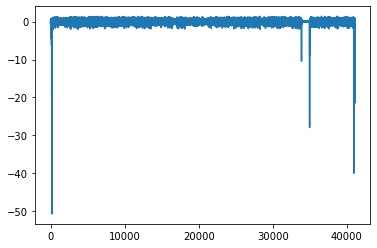

1.4186959999999544


In [27]:
plt.plot(np.diff(uff))
plt.show()
print(np.max(np.diff(uff)))

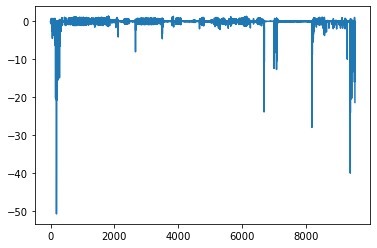

1.3295489999998154


In [28]:
plt.plot(np.diff(ff))
plt.show()
print(np.max(np.diff(ff)))

In [32]:
uniform_dat = '/datax/scratch/benjb/bliss_LSCX_test/quick_test/uniform_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000_SNR_10_L1_10.dat'
power_law_dat = '/datax/scratch/benjb/bliss_LSCX_test/quick_test/power_law_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000_SNR_10_L1_10.dat'

In [62]:
# uniform fiducial

bliss_snr_list = np.concatenate((np.arange(start=10, stop=36, step=5), [40, 50, 75, 100, 150, 200]))
bliss_snr_list = np.array([10,15,20,25,30,35,40,50,75])
bliss_l1_list = np.array([5,10,15,20,25,30,35,40,45,50])

bliss_average_factor_vec = []

snrs = []
l1s = []
underestimation_factors = []

fps = []
tps = []
fns = []
precisions = []
recalls = []

a = np.load(f'/datax/scratch/benjb/bliss_LSCX_test/quick_test/uniform_injections_freq_DR_snr_widths_MESSIER031_0057.npy')
pfreqs = a[0]
drifts = a[1]
snrvec = a[2]

#fig, ax = plt.subplots(1,1,figsize=(10,10))

for snr in bliss_snr_list:

    for l1 in bliss_l1_list:
        snr = 10
        l1 = 10
        print(snr, l1)

        dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/power_law/L/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_{snr}_L1_{l1}.dat')

        snrs.append(snr)
        l1s.append(l1)

        recorded_snrvec = []

        if len(dats) == 0:
            underestimation_factors.append(0)
            continue

        dat = dats[0]
        #print(dat)
        dat = uniform_dat

        df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
        ff = df['freq_start'].values
        dd = df['Drift_Rate'].values
        ss = df['SNR'].values
        n_inj = len(pfreqs)

        skip_count = 0
        got_freqs = []
        got_snrs = []
        got_drifts = []
        missed_freqs = []
        missed_snrs = []
        missed_drifts = []

        for i in range(n_inj):
            # check whether hit should be counted toward TP+FN
            if snrvec[i] < snr:
                skip_count += 1
                continue
            pf = pfreqs[i]
            pdiffvec = ff - pf
            d = drifts[i]
            s = snrvec[i]
            best_candidate_idxs = np.where(np.abs(pdiffvec)*1000 < 2)[0]
            best_candidate_drifts = np.concatenate((dd[best_candidate_idxs], [100])) # add 100 as a fix for len-0 case
            if (np.min(np.abs(pdiffvec))*1000 < 2) & (np.min(np.abs(best_candidate_drifts-d)) < 0.5): # permit accuracy to within 2 kHz
                true_idx = best_candidate_idxs[np.argmin(np.abs(best_candidate_drifts-d))]
                recorded_snr = ss[true_idx]
                recorded_snrvec.append(recorded_snr)
                got_freqs.append(pf)
                got_drifts.append(d)
                got_snrs.append(s)
            else:
                recorded_snrvec.append(np.nan)
                missed_freqs.append(pf)
                missed_drifts.append(d)
                missed_snrs.append(s)
            #break
        tp = len(np.where(np.isnan(recorded_snrvec)==False)[0])
        fn = len(np.where(np.isnan(recorded_snrvec)==True)[0])
        fp = len(ff) - tp
        precision = tp/(tp+fp)
        recall = tp/(tp+fn)
        precisions.append(precision)
        recalls.append(recall)
        print(len(recorded_snrvec))
        print(len(snrvec))
        print('TP:', tp, 'FN:', fn, 'FP:', fp, 'SC:', skip_count)

        #plt.plot(sr, sp, color='orangered', alpha=0.1)
        #print(snrvec[::2][:10])
        #print(recorded_snrvec[:10])
        #plt.scatter(snrvec, recorded_snrvec, color='orangered', alpha=0.1, lw=0, marker='o')
        #plt.scatter(snrvec, recorded_snrvec, c=np.abs(drifts), cmap='cividis', alpha=0.2, lw=0, marker='o')
        #print(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[::2]))
        bliss_average_factor_vec.append(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[np.where(snrvec >= snr)[0]]))
        underestimation_factors.append(np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[np.where(snrvec >= snr)[0]]))
        break
    break

print(f'BLISS factor {np.average(bliss_average_factor_vec)}')

10 10
2343
2343
TP: 2112 FN: 231 FP: 59703 SC: 0
BLISS factor 2.7785347262701747


In [61]:
print(len(snrvec[np.where(snrvec<20)[0]]))
print(len(np.array(got_snrs)[np.where(np.array(got_snrs)<20)[0]]))
print(len(np.array(missed_snrs)[np.where(np.array(missed_snrs)<20)[0]]))

22
7
15


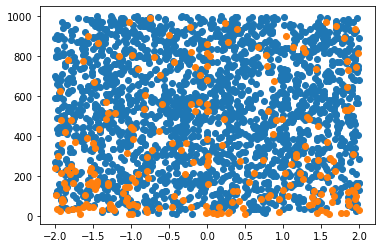

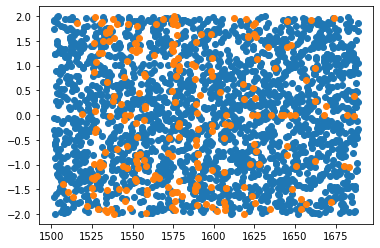

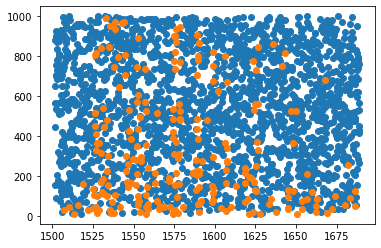

In [63]:
plt.scatter(got_drifts, got_snrs)
plt.scatter(missed_drifts, missed_snrs)
#plt.yscale('log')
plt.show()
plt.scatter(got_freqs, got_drifts)
plt.scatter(missed_freqs, missed_drifts)
plt.show()
plt.scatter(got_freqs, got_snrs)
plt.scatter(missed_freqs, missed_snrs)
#plt.yscale('log')
plt.show()

In [38]:
uff = np.copy(ff)

In [55]:
# power law

bliss_snr_list = np.concatenate((np.arange(start=10, stop=36, step=5), [40, 50, 75, 100, 150, 200]))
bliss_snr_list = np.array([10,15,20,25,30,35,40,50,75])
bliss_l1_list = np.array([5,10,15,20,25,30,35,40,45,50])

bliss_average_factor_vec = []

snrs = []
l1s = []
underestimation_factors = []

fps = []
tps = []
fns = []
precisions = []
recalls = []

a = np.load(f'/datax/scratch/benjb/bliss_LSCX_test/quick_test/power_law_injections_freq_DR_snr_widths_MESSIER031_0057.npy')
pfreqs = a[0]
drifts = a[1]
snrvec = a[2]

#fig, ax = plt.subplots(1,1,figsize=(10,10))

for snr in bliss_snr_list:

    for l1 in bliss_l1_list:
        snr = 10
        l1 = 10
        print(snr, l1)

        dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/power_law/L/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_{snr}_L1_{l1}.dat')

        snrs.append(snr)
        l1s.append(l1)

        recorded_snrvec = []

        if len(dats) == 0:
            underestimation_factors.append(0)
            continue

        dat = dats[0]
        #print(dat)
        dat = power_law_dat

        df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
        ff = df['freq_start'].values
        dd = df['Drift_Rate'].values
        ss = df['SNR'].values
        n_inj = len(pfreqs)

        skip_count = 0
        got_freqs = []
        got_snrs = []
        got_drifts = []
        missed_freqs = []
        missed_snrs = []
        missed_drifts = []

        for i in range(n_inj):
            # check whether hit should be counted toward TP+FN
            if snrvec[i] < snr:
                skip_count += 1
                continue
            pf = pfreqs[i]
            pdiffvec = ff - pf
            d = drifts[i]
            s = snrvec[i]
            best_candidate_idxs = np.where(np.abs(pdiffvec)*1000 < 2)[0]
            best_candidate_drifts = np.concatenate((dd[best_candidate_idxs], [100])) # add 100 as a fix for len-0 case
            if (np.min(np.abs(pdiffvec))*1000 < 2) & (np.min(np.abs(best_candidate_drifts-d)) < 0.5): # permit accuracy to within 2 kHz
                true_idx = best_candidate_idxs[np.argmin(np.abs(best_candidate_drifts-d))]
                recorded_snr = ss[true_idx]
                recorded_snrvec.append(recorded_snr)
                got_freqs.append(pf)
                got_drifts.append(d)
                got_snrs.append(s)
            else:
                recorded_snrvec.append(np.nan)
                missed_freqs.append(pf)
                missed_drifts.append(d)
                missed_snrs.append(s)
            #break
        tp = len(np.where(np.isnan(recorded_snrvec)==False)[0])
        fn = len(np.where(np.isnan(recorded_snrvec)==True)[0])
        fp = len(ff) - tp
        precision = tp/(tp+fp)
        recall = tp/(tp+fn)
        precisions.append(precision)
        recalls.append(recall)
        print(len(recorded_snrvec))
        print(len(snrvec))
        print('TP:', tp, 'FN:', fn, 'FP:', fp, 'SC:', skip_count)

        #plt.plot(sr, sp, color='orangered', alpha=0.1)
        #print(snrvec[::2][:10])
        #print(recorded_snrvec[:10])
        #plt.scatter(snrvec, recorded_snrvec, color='orangered', alpha=0.1, lw=0, marker='o')
        #plt.scatter(snrvec, recorded_snrvec, c=np.abs(drifts), cmap='cividis', alpha=0.2, lw=0, marker='o')
        #print(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[::2]))
        bliss_average_factor_vec.append(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[np.where(snrvec >= snr)[0]]))
        underestimation_factors.append(np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[np.where(snrvec >= snr)[0]]))
        break
    break

print(f'BLISS factor {np.average(bliss_average_factor_vec)}')

10 10
2343
2343
TP: 911 FN: 1432 FP: 60010 SC: 0
BLISS factor 3.897795822430944


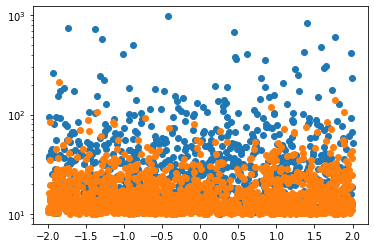

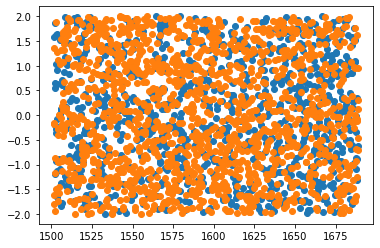

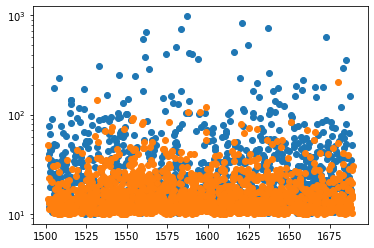

In [56]:
plt.scatter(got_drifts, got_snrs)
plt.scatter(missed_drifts, missed_snrs)
plt.yscale('log')
plt.show()
plt.scatter(got_freqs, got_drifts)
plt.scatter(missed_freqs, missed_drifts)
plt.show()
plt.scatter(got_freqs, got_snrs)
plt.scatter(missed_freqs, missed_snrs)
plt.yscale('log')
plt.show()

In [59]:
print(len(snrvec[np.where(snrvec<20)[0]]))
print(len(np.array(got_snrs)[np.where(np.array(got_snrs)<20)[0]]))
print(len(np.array(missed_snrs)[np.where(np.array(missed_snrs)<20)[0]]))

1459
356
1103


In [42]:
print(len(uff))
print(len(ff))

61815
60921


In [43]:
print(len(uff)-len(ff))

894
